In [17]:
from scripts.conf_file_finding import try_find_conf_file

try_find_conf_file()

Local configuration file found !!, no need to run the configuration (unless configuration has changed)


In [18]:
import pathlib

import datajoint as dj
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import u19_pipeline.acquisition as acquisition
import u19_pipeline.imaging_pipeline as ip
import u19_pipeline.lab as lab
import u19_pipeline.recording as recording
import u19_pipeline.utils.matlab_utils as mu

In [19]:
behavior = dj.create_virtual_module("behavior", "u19_behavior")

In [6]:
import re
import struct

import tifffile


def get_sync_info(input_file, data_type, frame_skip):
    if data_type == "uint16":
        num_bytes = 2
        struct_fmt = "<H"
        np_dtype = np.uint16
    else:
        raise NotImplementedError("I've only ever seen uint16 coded sync.")

    first_frame, skip_frames = frame_skip
    step = skip_frames + 1

    acquisition = 0.0
    epoch = []
    frame_time = []
    sync_time = []
    data_list = []

    # Regular expressions for for finding the field numbers. These are regularly formatted by scanimage.
    re_acq = re.compile(r"acquisitionNumbers\s*=\s*([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)")
    re_time = re.compile(r"frameTimestamps_sec\s*=\s*([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)")
    re_epoch = re.compile(r"epoch\s*=\s*\[(.*?)\]")
    re_i2c = re.compile(r"I2CData\s*=\s*\{(.*?)\}")
    re_i2c_inner = re.compile(r"([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*,\s*\[(.*?)\]")

    with tifffile.TiffFile(input_file) as tif:  # Open file
        pages_to_process = tif.pages[first_frame::step]  # Loop through the frames
        for i, page in enumerate(pages_to_process):
            if page is None:
                continue
            if hasattr(page, "aspage"):  # Force tiffframe to parse the full page
                page = page.aspage()

            tag = page.tags.get("ImageDescription")  # Extract ImageDescription tag
            # Error management: I'd be lazy, but Sue Ann coded them all up. So we should do the same.
            if tag is None:
                raise ValueError(
                    f"Failed to read image description tag for processed frame {i + 1}."
                )

            desc = tag.value
            if isinstance(desc, bytes):
                desc = desc.decode("utf-8", errors="replace")

            # Full oit acquisition Number (only extract from the first processed frame) - do we need this? Sue Ann had it, so here as well.
            if i == 0:
                match_acq = re_acq.search(desc)
                if match_acq:
                    acquisition = float(match_acq.group(1))
                else:
                    raise ValueError(
                        f"Failed to parse acquisitionNumbers for frame {i + 1}."
                    )

            # Pull out frame timestamp - do we needs this?
            match_time = re_time.search(desc)
            if match_time:
                frame_time.append(float(match_time.group(1)))
            else:
                raise ValueError(
                    f"Failed to parse frameTimestamps_sec for frame {i + 1}."
                )

            # Get epoch - do we need this?
            if i == 0:
                match_epoch = re_epoch.search(desc)
                if match_epoch:
                    epoch_str = match_epoch.group(1)
                    epoch = [
                        float(x) for x in re.split(r"[,\s]+", epoch_str.strip()) if x
                    ][:6]
                else:
                    raise ValueError(f"Failed to parse epoch for frame {i + 1}.")

            # And tje actual I2C stuff. This is important.
            match_i2c = re_i2c.search(desc)
            has_data = False

            if match_i2c:
                inner_str = match_i2c.group(1).strip()
                match_inner = re_i2c_inner.search(inner_str)

                if match_inner:
                    sync_time.append(float(match_inner.group(1)))
                    byte_str = match_inner.group(2)
                    byte_vals = [
                        int(x) for x in re.split(r"[,\s]+", byte_str.strip()) if x
                    ]

                    parsed_data = []
                    for j in range(
                        0, len(byte_vals), num_bytes
                    ):  # Unpack byte stream to target numeric datatypes
                        chunk = byte_vals[j : j + num_bytes]
                        if len(chunk) < num_bytes:
                            break

                        raw_bytes = bytes(chunk)
                        val = struct.unpack(struct_fmt, raw_bytes)[0]
                        parsed_data.append(val)

                    data_list.append(parsed_data)
                    has_data = True

            if not has_data:
                # If no I2C data payload is present, Manuel is sad. And grumpy. And hates the world.
                sync_time.append(np.nan)
                data_list.append(None)

    # Housekeeping with the empty frames
    # And converting to the clean Transposed 2D matrix structure [nData, nFrames]
    n_data = 0
    for d in data_list:
        if d is not None:
            n_data = len(d)
            break
    final_data = []
    for d in data_list:
        if d is None:
            final_data.append([0] * n_data if n_data > 0 else [])
        else:
            if len(d) != n_data:
                raise ValueError(
                    f"Inconsistent number of I2CData entries (expected {n_data}, got {len(d)})."
                )
            final_data.append(d)

    epoch = np.array([epoch], dtype=np.float64)
    frame_time = np.array([frame_time], dtype=np.float64)
    sync_time = np.array([sync_time], dtype=np.float64)
    data = np.array(final_data, dtype=np_dtype).T

    return acquisition, epoch, frame_time, sync_time, data

In [7]:
imaging_root_dir = dj.config["custom"]["imaging_root_data_dir"][0]

In [8]:
imaging_sessions = pd.DataFrame(
    (recording.Recording.BehaviorSession * ip.ImagingPipelineSession).fetch(
        order_by="session_date desc", as_dict=True
    )
)
imaging_sessions

,recording_id,subject_fullname,session_date,session_number
0,676,efonseca_ef512_act132,2026-05-14,1
1,677,efonseca_ef932_act131,2026-05-14,1
2,678,efonseca_ef932_act131,2026-05-12,1
3,679,efonseca_ef932_act131,2026-05-08,1
4,680,efonseca_ef932_act131,2026-05-07,2
5,669,efonseca_ef932_act131,2026-04-30,3
6,668,efonseca_ef932_act131,2026-04-23,1
7,187,efonseca_ef771_act2P112,2023-02-03,0
8,175,efonseca_ef771_act2P112,2023-01-20,3
9,169,efonseca_ef771_act2P112,2023-01-18,0


In [9]:
key = imaging_sessions.loc[0, :].to_dict()
key
img_key = dict()
img_key["recording_id"] = key.pop("recording_id")
session_key = key
session_key

{'subject_fullname': 'efonseca_ef512_act132',
 'session_date': datetime.date(2026, 5, 14),
 'session_number': 1}

In [10]:
imaging_dir = (recording.Recording & img_key).fetch1("recording_directory")
imaging_dir = pathlib.Path(imaging_root_dir, imaging_dir)
imaging_dir

PosixPath('/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026')

In [11]:
imaging_files = [
    file.as_posix() for file in imaging_dir.rglob("*.tif") if file.is_file()
]
imaging_files.sort()
imaging_files

['/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00001.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00002.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00003.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00004.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00005.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00006.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_05142026_00001_00007.tif',
 '/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef512_act132/20260514_g1/05142026/act132_ppc_051

In [12]:
behavior_data = (behavior.SpatialTimeBlobs & session_key).fetch(as_dict=True)
session_time = behavior_data[0]["cumulative_session_time"].flatten()
beh_iteration_matrix = behavior_data[0]["iteration_matrix"]
beh_iteration_matrix

array([[  1.,   1.,   1.],
       [  1.,   1.,   2.],
       [  1.,   1.,   3.],
       ...,
       [  2., 189., 485.],
       [  2., 189., 486.],
       [  2., 189., 487.]], shape=(266488, 3))

In [13]:
path = (acquisition.SessionStarted & session_key).fetch1(
    "new_remote_path_behavior_file"
)
mat_file = lab.Path().get_local_path2(path)
df_behavior_file = mu.convert_behavior_file(mat_file)

A working matlab version was not found. Code version, animal protocol, type of trial, and choice could not be saved to NWB.


In [ ]:
data = mu.convert_mat_file_to_dict(mat_file)
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Thu May 14 15:28:51 2026',
 '__version__': '1.0',
 '__globals__': [],
 'log': <scipy.io.matlab._mio5_params.mat_struct at 0x7f9dfcf2ff20>,
 '__function_workspace__': array([[ 0,  1, 73, ...,  0,  0,  0]], shape=(1, 100856), dtype=uint8)}

In [16]:
data["log"]

In [20]:
input_file = "/mnt/cup/braininit/Data/Raw/imaging/efonseca/efonseca_ef932_act131/20260518_g1/05182026/ef932_act131_ppc_05182026b_00003_00001.tif"

In [21]:
result = get_sync_info(input_file, "uint16", [0, 0])

In [22]:
result

(1.0,
 array([[2026.   ,    5.   ,   18.   ,   14.   ,   59.   ,   49.252]]),
 array([[0.00000000e+00, 1.99157800e-02, 3.98315300e-02, ...,
         3.97720501e+01, 3.97919661e+01, 3.98118821e+01]], shape=(1, 2000)),
 array([[        nan,         nan,         nan, ..., 39.77918732,
         39.80417125, 39.8285152 ]], shape=(1, 2000)),
 array([[  0,   0,   0, ...,   1,   1,   1],
        [  0,   0,   0, ...,   3,   3,   3],
        [  0,   0,   0, ..., 596, 598, 600]], shape=(3, 2000), dtype=uint16))

In [71]:
result[1][0]

array([2026.   ,    5.   ,   14.   ,   12.   ,   46.   ,   43.958])

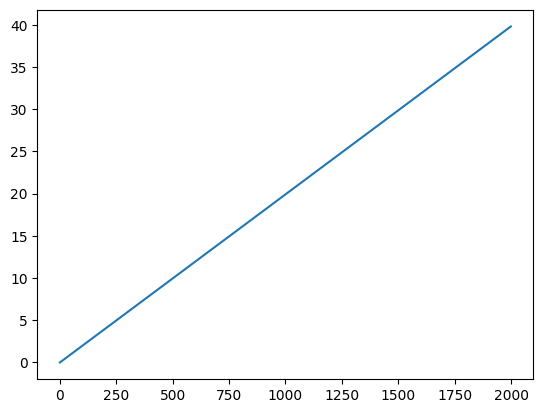

In [70]:
plt.plot(result[2][0])

In [59]:
desc = result[5].value

In [60]:
desc

'frameNumbers = 2000\nacquisitionNumbers = 1\nframeNumberAcquisition = 2000\nframeTimestamps_sec = 161.815112400\nacqTriggerTimestamps_sec = -0.000016300\nnextFileMarkerTimestamps_sec = -1.000000000\nendOfAcquisition = 0\nendOfAcquisitionMode = 0\ndcOverVoltage = 0\nepoch = [2021  2  8 18 12 23.750]\nauxTrigger0 = []\nauxTrigger1 = []\nauxTrigger2 = []\nauxTrigger3 = []\nI2CData = {{161.820946700, [2,0,12,0,112,0]} {161.829012700, [2,0,12,0,113,0]} {161.837914700, [2,0,12,0,114,0]} {161.845967750, [2,0,12,0,115,0]} {161.854824750, [2,0,12,0,116,0]} {161.862882750, [2,0,12,0,117,0]} {161.870797800, [2,0,12,0,118,0]} {161.879988800, [2,0,12,0,119,0]} {161.888838800, [2,0,12,0,120,0]} }'